# Training a 1D-CNN model in PyTorch to classify brain activities from EEG.


### Setp


In [1]:
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn import preprocessing, model_selection
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Python executable:", __import__("sys").executable)
print("Torch version:", torch.__version__)
print("Device:", DEVICE)


Python executable: /opt/anaconda3/envs/py310/bin/python
Torch version: 2.2.2
Device: cpu


### Constants and configs


In [2]:
RAW_PATH = Path("EEG/eeg-data.csv")
LABELS_JSON_PATH = Path("labels.json")
REPORT_DIR = Path("outputs/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

USE_MAJOR_CLASSES = True
SEQ_LEN = 512
BATCH_SIZE = 128
MAX_EPOCHS = 5
EARLY_STOP_PATIENCE = 10
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.25
LABEL_SMOOTHING = 0.08
MAX_GRAD_NORM = 1.0

print("Raw exists:", RAW_PATH.exists())
print("labels.json exists:", LABELS_JSON_PATH.exists())
print("Report dir:", REPORT_DIR)

Raw exists: True
labels.json exists: True
Report dir: outputs/reports


## Utility functions


In [3]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    arr = np.fromstring(text, sep=",", dtype=np.float32)
    if arr.size == 0:
        return None
    return arr


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)


if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))


def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

## Lodaing the data


In [21]:
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
print("Data shape:", eeg_data.shape)
print("Columns:", eeg_data.columns)

Data shape: (30013, 13)
Columns: Index(['Unnamed: 0', 'id', 'indra_time', 'browser_latency', 'reading_time',
       'attention_esense', 'meditation_esense', 'eeg_power', 'raw_values',
       'signal_quality', 'createdAt', 'updatedAt', 'label'],
      dtype='object')


In [22]:
# Let's drop the unwanted/unnecessary columns:
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns:", eeg_data.shape)

# Classes in the data:
eeg_data['label'].value_counts(dropna=False)

Data shape after dropping unnecessary columns: (30013, 4)


label
unlabeled            20054
relax                  934
music                  932
video-ver2             481
thinkOfItems-ver2      481
                     ...  
colorRound4-5           32
colorRound4-6           32
colorRound4-2           30
colorRound4-4           29
colorRound4-1           29
Name: count, Length: 68, dtype: int64

In [23]:
# we drop the "unlabeled" samples:
eeg_data = eeg_data[eeg_data['label'] != 'unlabeled']
print("Data shape after dropping unlabeled:", eeg_data.shape)

Data shape after dropping unlabeled: (9959, 4)


In [ ]:
# collate the minor classes into major ones:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Unique classes after collating minor classes into major ones: \n\t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9959, 4)
Unique classes after collating minor classes into major ones: 
	19


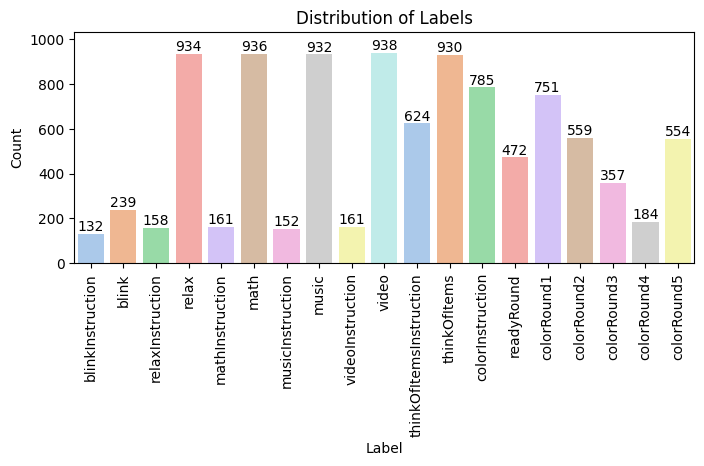

In [28]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

## Normalizing the raw values


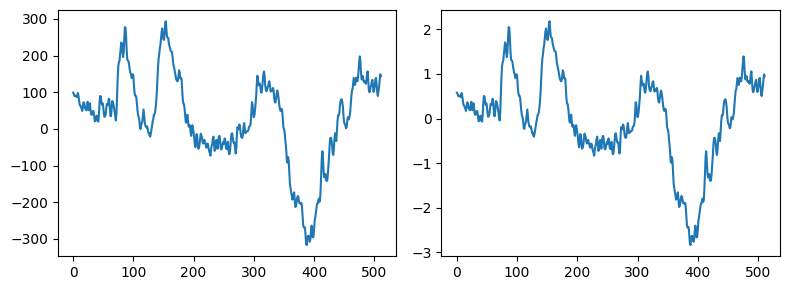

In [48]:
scaler = preprocessing.StandardScaler()
eeg_data['normalized_raw_values'] = eeg_data['raw_values'].apply(lambda x: scaler.fit_transform(x.reshape(-1, 1)).flatten() if x is not None else None)
fig, axs = plt.subplots(1,2, figsize=(8, 3))
axs[0].plot(eeg_data['raw_values'][0], label='Raw Values')
axs[1].plot(eeg_data['normalized_raw_values'][0], label='Normalized Raw Values')
plt.tight_layout()
plt.show()